In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [9]:
df.duplicated().sum()

np.int64(107)

In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")

print(df.head())
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nInformation:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nStatistics:")
print(df.describe())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Shape: (891, 15)

Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In

In [12]:

clean_df = df.copy()

print("Original dataset shape:", clean_df.shape)

Original dataset shape: (891, 15)


In [13]:
# Check number of duplicate rows
print("Duplicate rows before cleaning:", clean_df.duplicated().sum())

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Check shape after removing duplicates
print("Dataset shape after removing duplicates:", clean_df.shape)

# Check duplicates again
print("Duplicate rows after cleaning:", clean_df.duplicated().sum())

Duplicate rows before cleaning: 107
Dataset shape after removing duplicates: (784, 15)
Duplicate rows after cleaning: 0


In [14]:
print(clean_df.isnull().sum())

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64


In [15]:
# Check the median age
median_age = clean_df['age'].median()

print("Median age:", median_age)

# Fill missing age values with the median
clean_df['age'] = clean_df['age'].fillna(median_age)

# Check missing values again
print("Missing age values after cleaning:", clean_df['age'].isnull().sum())

Median age: 28.25
Missing age values after cleaning: 0


In [16]:
# Check the most frequent value
print("Most frequent embarked value:", clean_df['embarked'].mode()[0])

# Fill missing values with the mode
clean_df['embarked'] = clean_df['embarked'].fillna(
    clean_df['embarked'].mode()[0]
)

print("Missing embarked values after cleaning:",
      clean_df['embarked'].isnull().sum())

Most frequent embarked value: S
Missing embarked values after cleaning: 0


In [17]:
# Fill missing embark_town values using the mode
clean_df['embark_town'] = clean_df['embark_town'].fillna(
    clean_df['embark_town'].mode()[0]
)

print("Missing embark_town values after cleaning:",
      clean_df['embark_town'].isnull().sum())

Missing embark_town values after cleaning: 0


In [18]:
# Remove deck because most of its values are missing
clean_df = clean_df.drop(columns=['deck'])

print("Dataset shape after removing deck:", clean_df.shape)

Dataset shape after removing deck: (784, 14)


In [19]:
print("Final missing-value count:")
print(clean_df.isnull().sum())

Final missing-value count:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [20]:
print("Final dataset shape:", clean_df.shape)

print("\nFirst 5 rows:")
print(clean_df.head())

print("\nFinal data types:")
print(clean_df.dtypes)

Final dataset shape: (784, 14)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True  

Final data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked        

In [21]:
print(clean_df['survived'].value_counts())

survived
0    461
1    323
Name: count, dtype: int64


In [22]:
print("\nSurvival percentage:")
print(clean_df['survived'].value_counts(normalize=True) * 100)


Survival percentage:
survived
0    58.80102
1    41.19898
Name: proportion, dtype: float64


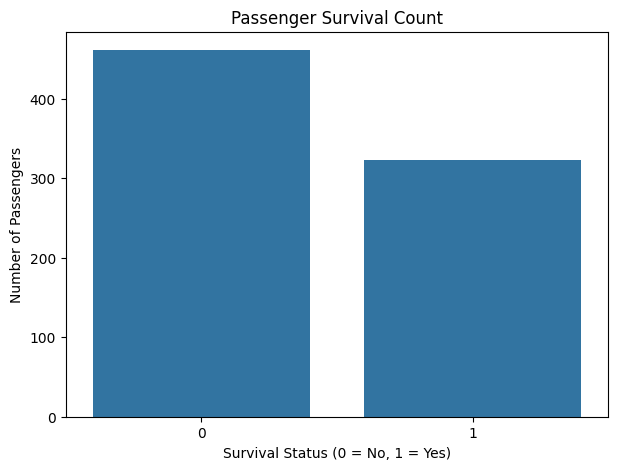

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(data=clean_df, x='survived')

plt.title('Passenger Survival Count')
plt.xlabel('Survival Status (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()

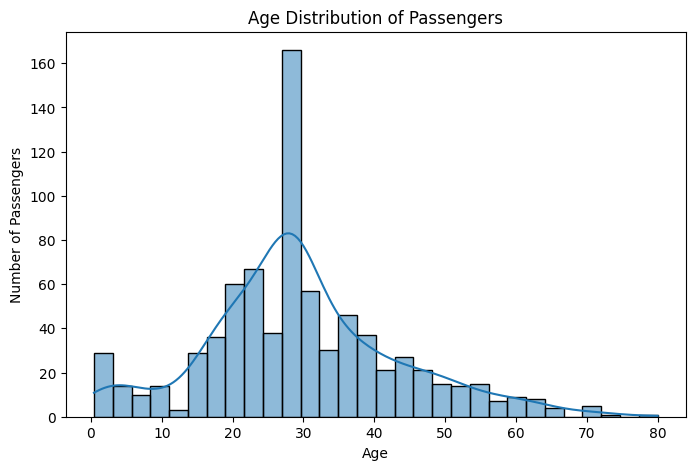

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(data=clean_df, x='age', bins=30, kde=True)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

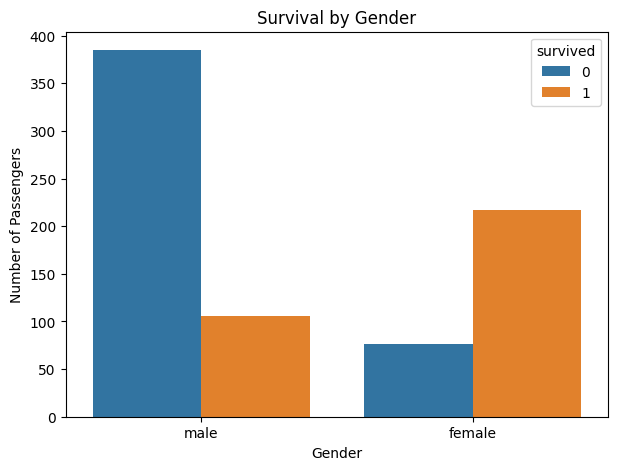

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(data=clean_df, x='sex', hue='survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

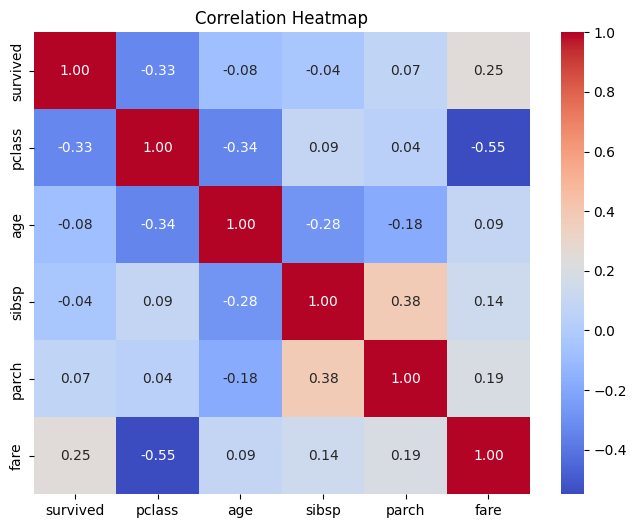

In [26]:
plt.figure(figsize=(8, 6))

numeric_df = clean_df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [27]:
print("Final dataset shape:", clean_df.shape)
print(clean_df['survived'].value_counts())
print(clean_df['survived'].value_counts(normalize=True) * 100)

Final dataset shape: (784, 14)
survived
0    461
1    323
Name: count, dtype: int64
survived
0    58.80102
1    41.19898
Name: proportion, dtype: float64


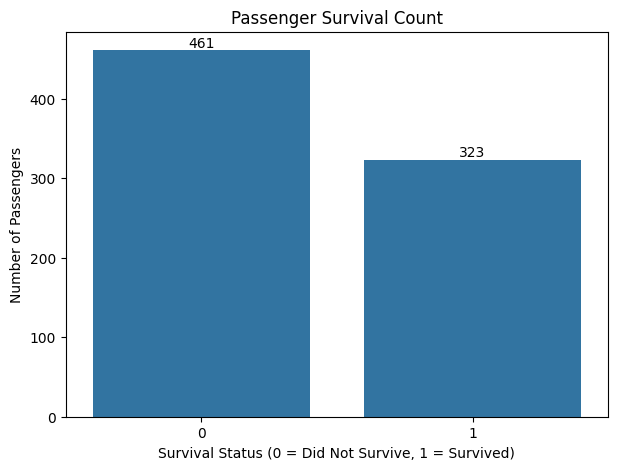

In [28]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=clean_df, x='survived')

plt.title('Passenger Survival Count')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

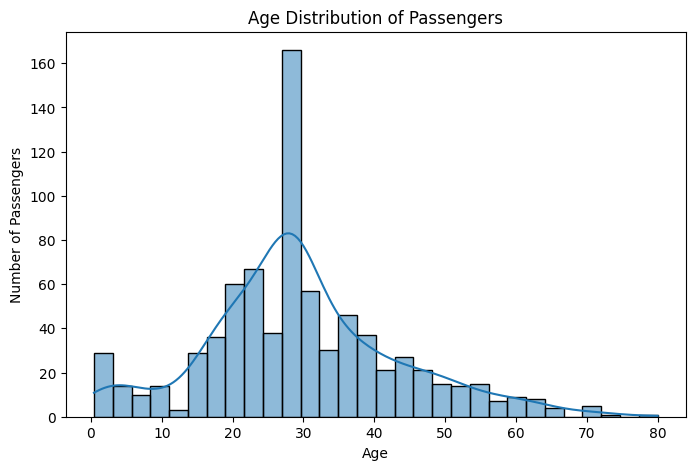

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(data=clean_df, x='age', bins=30, kde=True)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

In [30]:
# Gender-wise survival analysis
print("GENDER-WISE SURVIVAL")
print(pd.crosstab(clean_df['sex'], clean_df['survived']))

print("\nGender-wise survival percentage:")
print(pd.crosstab(
    clean_df['sex'],
    clean_df['survived'],
    normalize='index'
) * 100)


# Passenger class-wise survival analysis
print("\nPASSENGER CLASS-WISE SURVIVAL")
print(pd.crosstab(clean_df['class'], clean_df['survived']))

print("\nClass-wise survival percentage:")
print(pd.crosstab(
    clean_df['class'],
    clean_df['survived'],
    normalize='index'
) * 100)


# Age statistics
print("\nAGE STATISTICS")
print(clean_df['age'].describe())


# Fare statistics
print("\nFARE STATISTICS")
print(clean_df['fare'].describe())

GENDER-WISE SURVIVAL
survived    0    1
sex               
female     76  217
male      385  106

Gender-wise survival percentage:
survived          0          1
sex                           
female    25.938567  74.061433
male      78.411405  21.588595

PASSENGER CLASS-WISE SURVIVAL
survived    0    1
class             
First      79  135
Second     81   84
Third     301  104

Class-wise survival percentage:
survived          0          1
class                         
First     36.915888  63.084112
Second    49.090909  50.909091
Third     74.320988  25.679012

AGE STATISTICS
count    784.000000
mean      29.650408
std       13.734925
min        0.420000
25%       22.000000
50%       28.250000
75%       36.000000
max       80.000000
Name: age, dtype: float64

FARE STATISTICS
count    784.000000
mean      34.711740
std       52.160151
min        0.000000
25%        8.050000
50%       15.900000
75%       34.109350
max      512.329200
Name: fare, dtype: float64


In [31]:
numeric_df = clean_df.select_dtypes(include='number')

print("Correlation Matrix:")
print(numeric_df.corr().round(2))

Correlation Matrix:
          survived  pclass   age  sibsp  parch  fare
survived      1.00   -0.33 -0.08  -0.04   0.07  0.25
pclass       -0.33    1.00 -0.34   0.09   0.04 -0.55
age          -0.08   -0.34  1.00  -0.28  -0.18  0.09
sibsp        -0.04    0.09 -0.28   1.00   0.38  0.14
parch         0.07    0.04 -0.18   0.38   1.00  0.19
fare          0.25   -0.55  0.09   0.14   0.19  1.00


In [32]:
print("FINAL DATASET SUMMARY")
print("---------------------")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

FINAL DATASET SUMMARY
---------------------
Rows: 784
Columns: 14
Missing values: 0
Duplicate rows: 4


In [33]:
# Final duplicate removal after all cleaning steps

print("Duplicate rows before final removal:",
      clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates()

print("Duplicate rows after final removal:",
      clean_df.duplicated().sum())

print("Final dataset shape:", clean_df.shape)

Duplicate rows before final removal: 4
Duplicate rows after final removal: 0
Final dataset shape: (780, 14)


In [34]:
print("FINAL DATASET SUMMARY")
print("---------------------")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

FINAL DATASET SUMMARY
---------------------
Rows: 780
Columns: 14
Missing values: 0
Duplicate rows: 0


In [35]:
print("Survival Count:")
print(clean_df['survived'].value_counts())

print("\nSurvival Percentage:")
print(clean_df['survived'].value_counts(normalize=True) * 100)

Survival Count:
survived
0    458
1    322
Name: count, dtype: int64

Survival Percentage:
survived
0    58.717949
1    41.282051
Name: proportion, dtype: float64


In [36]:
clean_df = clean_df.drop_duplicates()

print("Final dataset shape:", clean_df.shape)
print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

Final dataset shape: (780, 14)
Missing values: 0
Duplicate rows: 0


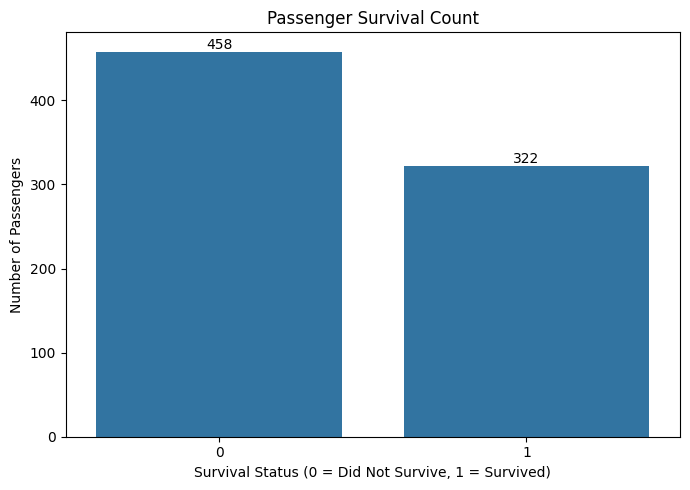

In [37]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=clean_df, x='survived')

plt.title('Passenger Survival Count')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

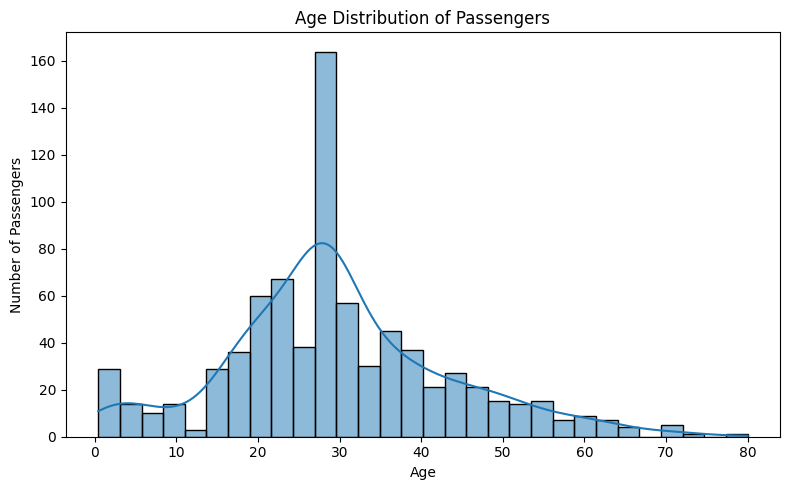

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(data=clean_df, x='age', bins=30, kde=True)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.tight_layout()
plt.show()

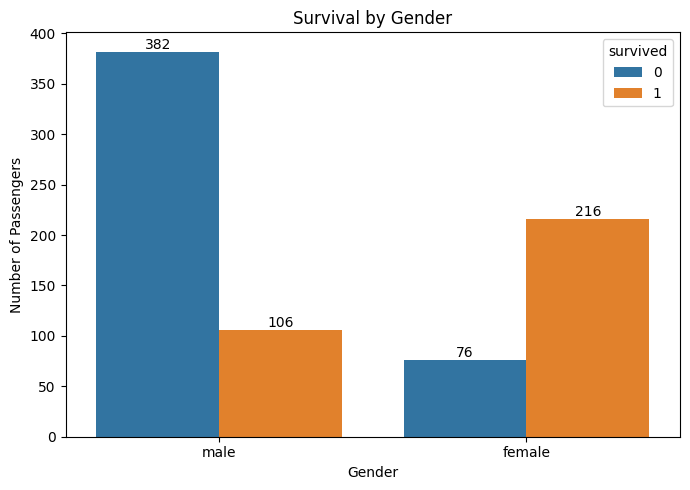

In [39]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=clean_df, x='sex', hue='survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

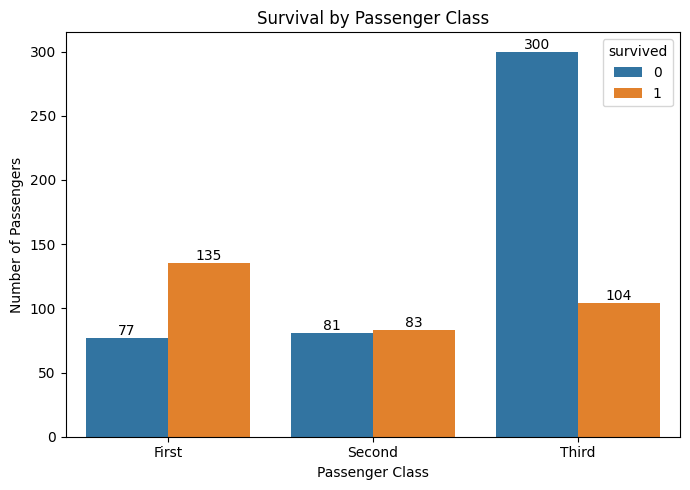

In [41]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=clean_df, x='class', hue='survived')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

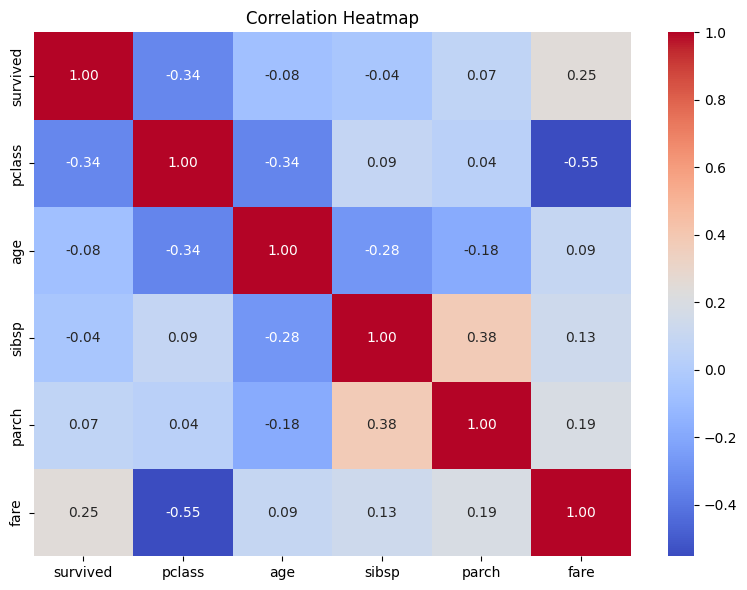

In [42]:
plt.figure(figsize=(8, 6))

numeric_df = clean_df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [43]:
print("===== FINAL EDA RESULTS =====")

print("\n1. Survival:")
print(clean_df['survived'].value_counts())
print((clean_df['survived'].value_counts(normalize=True) * 100).round(2))

print("\n2. Gender vs Survival:")
print(pd.crosstab(clean_df['sex'], clean_df['survived']))

print("\n3. Gender-wise Survival Percentage:")
print(
    (pd.crosstab(
        clean_df['sex'],
        clean_df['survived'],
        normalize='index'
    ) * 100).round(2)
)

print("\n4. Class vs Survival:")
print(pd.crosstab(clean_df['class'], clean_df['survived']))

print("\n5. Class-wise Survival Percentage:")
print(
    (pd.crosstab(
        clean_df['class'],
        clean_df['survived'],
        normalize='index'
    ) * 100).round(2)
)

print("\n6. Age Statistics:")
print(clean_df['age'].describe().round(2))

print("\n7. Correlation:")
print(
    clean_df.select_dtypes(include='number')
    .corr()
    .round(2)
)

===== FINAL EDA RESULTS =====

1. Survival:
survived
0    458
1    322
Name: count, dtype: int64
survived
0    58.72
1    41.28
Name: proportion, dtype: float64

2. Gender vs Survival:
survived    0    1
sex               
female     76  216
male      382  106

3. Gender-wise Survival Percentage:
survived      0      1
sex                   
female    26.03  73.97
male      78.28  21.72

4. Class vs Survival:
survived    0    1
class             
First      77  135
Second     81   83
Third     300  104

5. Class-wise Survival Percentage:
survived      0      1
class                 
First     36.32  63.68
Second    49.39  50.61
Third     74.26  25.74

6. Age Statistics:
count    780.00
mean      29.60
std       13.72
min        0.42
25%       21.75
50%       28.25
75%       36.00
max       80.00
Name: age, dtype: float64

7. Correlation:
          survived  pclass   age  sibsp  parch  fare
survived      1.00   -0.34 -0.08  -0.04   0.07  0.25
pclass       -0.34    1.00 -0.34   0.09   0.